# 03 — Scaling & the Elbow Method

**Goal:** get Recency, Frequency, and Monetary onto a comparable scale, then decide how many clusters (K) the data actually supports.

**Why scaling matters:** K-Means groups points by Euclidean distance. Recency ranges ~1-374 (days), Frequency ~1-209 (orders), Monetary ~£3.75-£280,206. Left unscaled, a large pound-difference in Monetary would swamp everything else in the distance calculation and the "clustering" would really just be sorting by spend.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

rfm = pd.read_csv("../data/rfm.csv")
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,93.059474,4.272015,2054.266459
std,1721.808492,100.012264,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.750000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


## 1. First attempt: StandardScaler on the raw values

This is the textbook-default approach. Let's see what it actually produces before assuming it's fine.

In [2]:
print("Skew (0 = symmetric, higher = long right tail):")
print(rfm[["Recency", "Frequency", "Monetary"]].skew())

Skew (0 = symmetric, higher = long right tail):
Recency       1.245826
Frequency    12.067031
Monetary     19.324953
dtype: float64


In [3]:
X_raw = rfm[["Recency", "Frequency", "Monetary"]]
X_raw_scaled = StandardScaler().fit_transform(X_raw)

km_naive = KMeans(n_clusters=4, random_state=42, n_init=10)
naive_labels = km_naive.fit_predict(X_raw_scaled)

print("Cluster sizes (naive StandardScaler, K=4):")
print(pd.Series(naive_labels).value_counts().sort_index())

Cluster sizes (naive StandardScaler, K=4):
0    3053
1      13
2    1061
3     211
Name: count, dtype: int64


**Problem:** Frequency and Monetary are heavily right-skewed (a handful of very high-spending, very frequent customers stretch the tail). StandardScaler's mean and standard deviation both get pulled by those extreme values, so it rescales *around* the skew rather than fixing it. The result above is one large "everyone normal" cluster plus progressively smaller clusters that are really just isolating outliers -- not four meaningfully different behavioral groups.

## 2. Fix: log-transform Frequency & Monetary before scaling

`log1p(x)` (= log(1+x), safe at x=0) compresses long right tails: the gap between spending £500 and £5,000 becomes comparable in scale to the gap between £5,000 and £50,000 (both "one order of magnitude"), instead of the raw-pound gap dwarfing everything. Recency's skew (~1.2) is mild enough to leave alone.

In [4]:
rfm_log = rfm.copy()
rfm_log["Frequency_log"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary_log"] = np.log1p(rfm_log["Monetary"])

features = ["Recency", "Frequency_log", "Monetary_log"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_log[features])

print("Skew after log transform:")
print(rfm_log[["Recency", "Frequency_log", "Monetary_log"]].skew())

Skew after log transform:
Recency          1.245826
Frequency_log    1.208652
Monetary_log     0.393553
dtype: float64


## 3. Elbow Method + silhouette score, K = 2..10

- **Inertia** (within-cluster sum of squares): always decreases as K grows -- look for where it stops dropping quickly.
- **Silhouette score** (-1 to 1): measures how well-separated clusters are, independent of K's monotonic bias. A second, corroborating signal.

In [5]:
results = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    results.append({
        "K": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_scaled, labels),
    })

results_df = pd.DataFrame(results)
results_df

,K,inertia,silhouette
0,2,6871.868483,0.406424
1,3,4298.733916,0.415605
2,4,3241.965669,0.379525
3,5,2760.816476,0.343318
4,6,2397.308551,0.331503
5,7,2166.883880,0.299898
6,8,1960.810943,0.299877
7,9,1819.594603,0.281593
8,10,1689.261328,0.283239


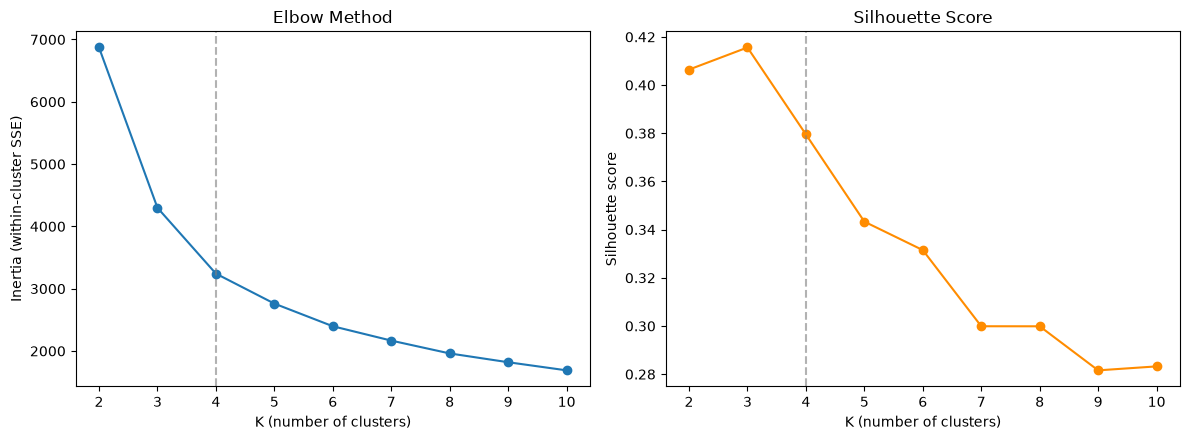

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(results_df["K"], results_df["inertia"], marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("K (number of clusters)")
axes[0].set_ylabel("Inertia (within-cluster SSE)")
axes[0].axvline(4, color="grey", linestyle="--", alpha=0.6)

axes[1].plot(results_df["K"], results_df["silhouette"], marker="o", color="darkorange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("K (number of clusters)")
axes[1].set_ylabel("Silhouette score")
axes[1].axvline(4, color="grey", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../outputs/elbow_silhouette.png", dpi=150)
plt.show()

## 4. Choosing K

Silhouette technically peaks at K=3 (0.42), with K=4 close behind (0.38 -- still "reasonable structure" by the usual >0.25 rule of thumb). The inertia curve bends clearly around K=3-4 and flattens after.

**Decision: K = 4.** Pure clustering-quality metrics would edge toward K=3, but K=4 costs very little quality and buys a lot of business communication value -- it maps cleanly onto four distinct, nameable behavioral groups (verified in the next notebook), which is what this project is actually for. This is a judgment call, not a default -- worth being able to explain, not just cite.

In [7]:
print(results_df.round(3).to_string(index=False))

 K  inertia  silhouette
 2 6871.868       0.406
 3 4298.734       0.416
 4 3241.966       0.380
 5 2760.816       0.343
 6 2397.309       0.332
 7 2166.884       0.300
 8 1960.811       0.300
 9 1819.595       0.282
10 1689.261       0.283


## Takeaways

- Ran StandardScaler on raw RFM values first -- and it produced degenerate, outlier-driven clusters, because Frequency/Monetary are heavily right-skewed. Not a hypothetical risk; it happened.
- Fixed it with `log1p` on Frequency and Monetary before scaling.
- Chose K=4 using inertia (Elbow) + silhouette score together, then made an explicit business-interpretability trade-off over the pure math optimum (K=3).

**Next up (`04_kmeans_clustering.ipynb`):** fit the final K=4 model, inspect each cluster's average Recency/Frequency/Monetary profile, and map cluster numbers to business labels (Champions / Loyal / At-Risk / Lost).